In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from pathlib import Path


In [2]:
# Define channel names and colors
channel_names = ['Mito', 'AGP', 'RNA', 'ER', 'DNA']
channel_colors = ['Reds', 'Oranges', 'Yellow', 'Greens', 'Blues']

# Define the base path and first image identifier
base_path = Path('../Cell_Profiler/cell_profiler_input/real_tiff/images')
image_id = 'r01c01f02_pred'  # First image


In [3]:
# Load all channels for the first image
channels = {}
for channel in channel_names:
    file_path = base_path / f'{image_id}_{channel}.tif'
    if file_path.exists():
        # Load the TIFF image
        img = Image.open(file_path)
        channels[channel] = np.array(img)
        print(f"Loaded {channel}: {channels[channel].shape}, dtype: {channels[channel].dtype}, range: [{channels[channel].min()}, {channels[channel].max()}]")
    else:
        print(f"Warning: {file_path} not found")


Loaded Mito: (512, 512), dtype: float32, range: [0.0, 1.0]
Loaded AGP: (512, 512), dtype: float32, range: [0.0, 1.0]
Loaded RNA: (512, 512), dtype: float32, range: [0.0, 1.0]
Loaded ER: (512, 512), dtype: float32, range: [0.0, 1.0]
Loaded DNA: (512, 512), dtype: float32, range: [0.0, 1.0]


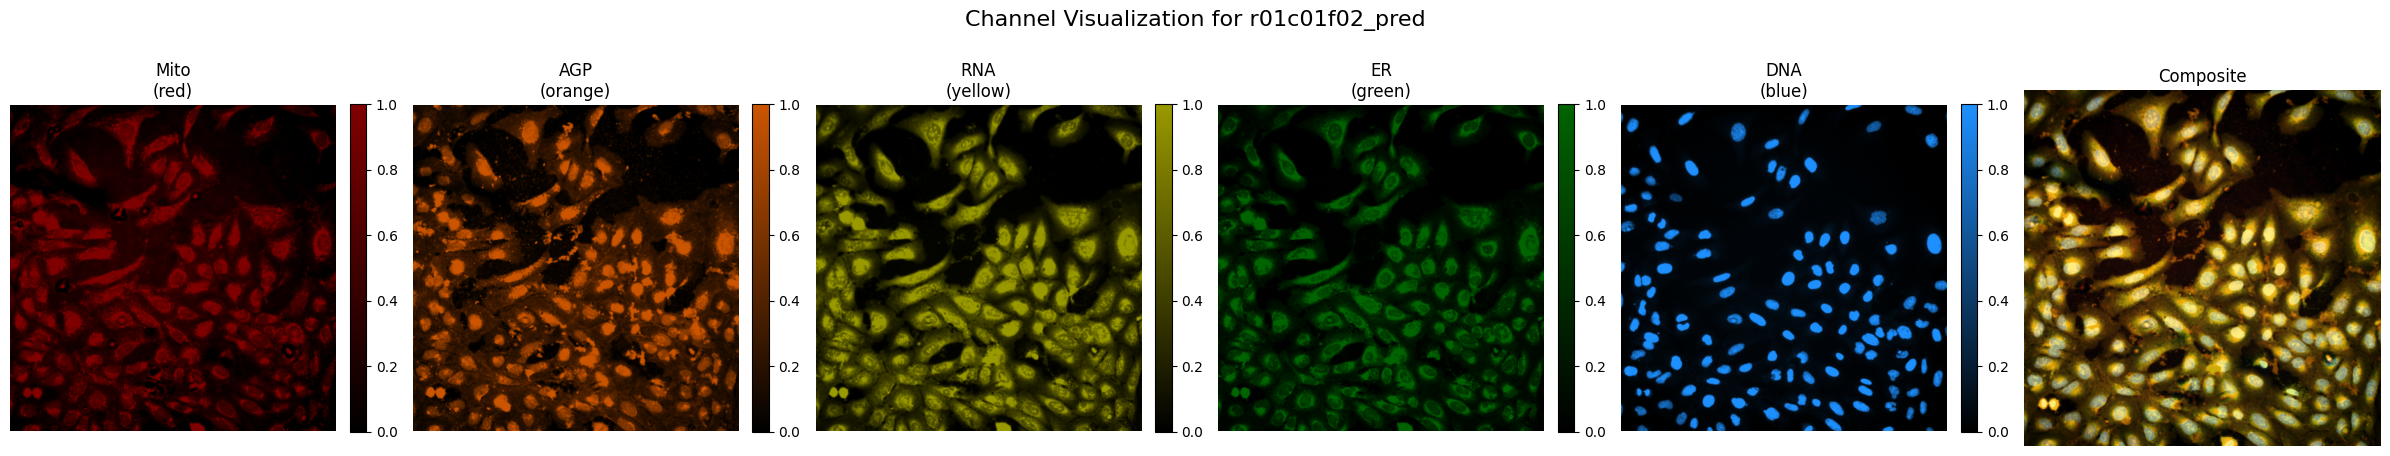

In [4]:
# Create the visualization
fig, axes = plt.subplots(1, 6, figsize=(24, 5))
fig.suptitle(f'Channel Visualization for {image_id}', fontsize=16)

# Create custom colormaps
from matplotlib.colors import LinearSegmentedColormap

# define hex for your pure colors
hex_cols = {
    'red':    '#800000',   # dark red
    'orange': '#CC5500',   # burnt orange
    'yellow': '#999900',   # darker mustard
    'green':  '#006400',   # dark green
    'blue':   '#1E90FF',   # medium blue (more vibrant than #00008B)
}

cmaps = {}
for name, hexc in hex_cols.items():
    cmaps[name] = LinearSegmentedColormap.from_list(
        f"{name}_cmap",
        [ (0.0, '#000000'),  (1.0, hexc)],
        N=256
    )

# Map channel names to colormap names
channel_to_cmap = {
    'Mito': 'red',
    'AGP': 'orange', 
    'RNA': 'yellow',
    'ER': 'green',
    'DNA': 'blue'
}

# Plot individual channels
for i, channel in enumerate(channel_names):
    if channel in channels:
        cmap_name = channel_to_cmap.get(channel, 'red')
        im = axes[i].imshow(channels[channel], cmap=cmaps[cmap_name])
        axes[i].set_title(f'{channel}\n({cmap_name})', fontsize=12)
        axes[i].axis('off')
        # Add colorbar
        plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
    else:
        axes[i].text(0.5, 0.5, f'{channel}\nNot Found', 
                    transform=axes[i].transAxes, ha='center', va='center')
        axes[i].axis('off')

# Create composite image (RGB representation)
if len(channels) >= 3:
    # Normalize each channel to 0-1 range
    normalized_channels = {}
    for channel in channel_names:
        if channel in channels:
            img = channels[channel].astype(np.float32)
            img_min, img_max = img.min(), img.max()
            if img_max > img_min:
                normalized_channels[channel] = (img - img_min) / (img_max - img_min)
            else:
                normalized_channels[channel] = img
    
    # Create composite using the actual colors we defined
    height, width = list(normalized_channels.values())[0].shape
    composite = np.zeros((height, width, 3))
    
    # Convert hex colors to RGB values (0-1 range)
    # Convert hex colors to RGB values (0-1 range)
    color_rgb = {}
    for channel, hex_color in hex_cols.items():
        # Convert hex to RGB (0-255) then normalize to (0-1)
        hex_color = hex_color.lstrip('#')
        r = int(hex_color[0:2], 16) / 255.0
        g = int(hex_color[2:4], 16) / 255.0
        b = int(hex_color[4:6], 16) / 255.0
        color_rgb[channel] = np.array([r, g, b])
    
    # Add each channel with its corresponding color
    for channel in channel_names:
        if channel in normalized_channels:
            # Use channel_to_cmap mapping to get the correct color key
            cmap_name = channel_to_cmap.get(channel, 'red')
            if cmap_name in color_rgb:
                color = color_rgb[cmap_name]
                for c in range(3):  # RGB channels
                    composite[:, :, c] += normalized_channels[channel] * color[c]
    composite = (composite - composite.min()) / (composite.max() - composite.min())
    # Add AGP to red channel (orange is red-ish)
    # Average the contributions and clip to valid range
    
    axes[5].imshow(composite)
    axes[5].set_title('Composite', fontsize=12)
    axes[5].axis('off')
else:
    axes[5].text(0.5, 0.5, 'Composite\nNot Available', 
                transform=axes[5].transAxes, ha='center', va='center')
    axes[5].axis('off')

plt.tight_layout()
plt.show()
